In [ ]:
"""
APM_52065_EP — Crypto Flash Crash October 2025
SECTION 7: Processus de Hawkes et Dynamique Auto-
excitante
  
Output: all figures saved as PDF 
        all tables printed to console 
"""
import ccxt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.optimize import minimize

In [21]:
# ============================================================
# 1. CHARGEMENT DONNÉES MINUTE — octobre 2025
# ============================================================

def fetch_ohlcv_full(symbol, timeframe='1m',
                     start='2025-10-01', end='2025-11-01'):
    exchange = ccxt.binance()
    since = exchange.parse8601(f'{start}T00:00:00Z')
    until = exchange.parse8601(f'{end}T00:00:00Z')
    all_data = []
    while since < until:
        ohlcv = exchange.fetch_ohlcv(symbol, timeframe,
                                      since=since, limit=1000)
        if not ohlcv:
            break
        all_data += ohlcv
        since = ohlcv[-1][0] + 1
    df = pd.DataFrame(all_data,
                      columns=['timestamp','open','high',
                               'low','close','volume'])
    df['timestamp'] = pd.to_datetime(df['timestamp'], unit='ms')
    df.set_index('timestamp', inplace=True)
    return df[df.index < pd.Timestamp(end)]

print("Chargement BTC 1min...")
btc_1m = fetch_ohlcv_full('BTC/USDT', '1m')
print("Chargement ETH 1min...")
eth_1m = fetch_ohlcv_full('ETH/USDT', '1m')

btc_ret = np.log(btc_1m['close']).diff().dropna()
eth_ret = np.log(eth_1m['close']).diff().dropna()

t0 = btc_ret.index[0]

def to_hours(index, t0):
    return np.array([(t - t0).total_seconds() / 3600
                     for t in index])

def get_events_neg(returns, t0, q=0.05):
    seuil = returns.quantile(q)
    return to_hours(returns[returns < seuil].index, t0)

def get_events_pos(returns, t0, q=0.95):
    seuil = returns.quantile(q)
    return to_hours(returns[returns > seuil].index, t0)

ev_btc_neg = get_events_neg(btc_ret, t0)
ev_eth_neg = get_events_neg(eth_ret, t0)
ev_btc_pos = get_events_pos(btc_ret, t0)
ev_eth_pos = get_events_pos(eth_ret, t0)

print(f"\nÉvénements BTC négatifs : {len(ev_btc_neg)}")
print(f"Événements ETH négatifs : {len(ev_eth_neg)}")
print(f"Événements BTC positifs : {len(ev_btc_pos)}")
print(f"Événements ETH positifs : {len(ev_eth_pos)}")

Chargement BTC 1min...
Chargement ETH 1min...

Événements BTC négatifs : 2232
Événements ETH négatifs : 2232
Événements BTC positifs : 2232
Événements ETH positifs : 2232


In [22]:
# ============================================================
# 2. FONCTIONS MLE — HAWKES UNIVARIÉ ET MULTIVARIÉ
# ============================================================

def compute_R(events, beta):
    """Calcule le vecteur récursif R pour l'intensité."""
    n = len(events)
    R = np.zeros(n)
    for i in range(1, n):
        R[i] = np.exp(-beta * (events[i] - events[i-1])) * (1 + R[i-1])
    return R

def neg_ll_univariate(params, events, T):
    """Log-vraisemblance négative — Hawkes univarié."""
    mu, alpha, beta = params
    if mu <= 0 or alpha <= 0 or beta <= 0:
        return np.inf
    if alpha / beta >= 1:
        return np.inf

    R = compute_R(events, beta)
    intensities = mu + alpha * R
    intensities = np.maximum(intensities, 1e-10)

    integral = mu * T + (alpha / beta) * np.sum(
        1 - np.exp(-beta * (T - events)))

    ll = -integral + np.sum(np.log(intensities))
    return -ll

def fit_hawkes_uni(events, T, n_starts=15):
    """Estimation MLE Hawkes univarié."""
    best_res, best_val = None, np.inf
    np.random.seed(42)
    for _ in range(n_starts):
        mu0    = np.random.uniform(0.001, 1.0)
        alpha0 = np.random.uniform(0.001, 0.5)
        beta0  = np.random.uniform(0.1,   3.0)
        res = minimize(
            neg_ll_univariate,
            x0=[mu0, alpha0, beta0],
            args=(events, T),
            method='L-BFGS-B',
            bounds=[(1e-6, None), (1e-6, None), (1e-6, None)]
        )
        if res.success and res.fun < best_val:
            best_val = res.fun
            best_res = res
    return best_res.x  # mu, alpha, beta

def neg_ll_bivariate(params, ev1, ev2, T):
    """Log-vraisemblance négative — Hawkes bivarié."""
    mu1, mu2, a11, a12, a21, a22, beta = params
    if any(p <= 0 for p in params):
        return np.inf
    if (a11 + a12) / beta >= 1 or (a21 + a22) / beta >= 1:
        return np.inf

    # Fusionner et trier les deux flux
    all_ev  = np.concatenate([ev1, ev2])
    labels  = np.concatenate([np.zeros(len(ev1)),
                               np.ones(len(ev2))])
    order   = np.argsort(all_ev)
    all_ev  = all_ev[order]
    labels  = labels[order]

    # Terme intégrale
    integral = (mu1 + mu2) * T
    integral += (a11 + a21) / beta * np.sum(
        1 - np.exp(-beta * (T - ev1)))
    integral += (a12 + a22) / beta * np.sum(
        1 - np.exp(-beta * (T - ev2)))

    # Terme log-intensités avec récursion
    R1, R2   = 0.0, 0.0
    prev_t   = 0.0
    log_sum  = 0.0

    for t, lab in zip(all_ev, labels):
        dt  = t - prev_t
        R1 *= np.exp(-beta * dt)
        R2 *= np.exp(-beta * dt)

        lam1 = max(mu1 + a11 * R1 + a12 * R2, 1e-10)
        lam2 = max(mu2 + a21 * R1 + a22 * R2, 1e-10)

        if lab == 0:
            log_sum += np.log(lam1)
            R1 += 1
        else:
            log_sum += np.log(lam2)
            R2 += 1
        prev_t = t

    return integral - log_sum

def fit_hawkes_biv(ev1, ev2, T, n_starts=15):
    """Estimation MLE Hawkes bivarié."""
    best_res, best_val = None, np.inf
    np.random.seed(42)
    for _ in range(n_starts):
        p0      = np.random.uniform(0.001, 0.3, 7)
        p0[6]   = np.random.uniform(0.5, 3.0)
        res = minimize(
            neg_ll_bivariate,
            x0=p0,
            args=(ev1, ev2, T),
            method='L-BFGS-B',
            bounds=[(1e-6, None)] * 7
        )
        if res.success and res.fun < best_val:
            best_val = res.fun
            best_res = res
    mu1, mu2, a11, a12, a21, a22, beta = best_res.x
    return {
        'mu'  : [mu1, mu2],
        'A'   : np.array([[a11, a12], [a21, a22]]),
        'beta': beta
    }

T = float(ev_btc_neg[-1])




BLOC A — HAWKES CLASSIQUE UNIVARIÉ


C:\Users\Lenovo\AppData\Roaming\Python\Python312\site-packages\scipy\optimize\_numdiff.py:576: RuntimeWarning: invalid value encountered in subtract
  df = fun(x) - f0



BTC :
  μ     = 0.510099  événements/heure
  α     = 1.273488
  β     = 1.532029
  n=α/β = 0.831243  (⚠ critique)
  Durée moy. excitation = 0.653h = 39.2 min

ETH :
  μ     = 0.502756  événements/heure
  α     = 1.260312
  β     = 1.510280
  n=α/β = 0.834489  (⚠ critique)
  Durée moy. excitation = 0.662h = 39.7 min

BLOC B — HAWKES CLASSIQUE MULTIVARIÉ BTC <-> ETH


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_28716\1731007813.py:72: RuntimeWarning: overflow encountered in exp
  1 - np.exp(-beta * (T - ev2)))



Baseline : μ_BTC=0.000001, μ_ETH=2.497492
β = 61.494632

Matrice d'adjacence :
  BTC→BTC : 4.655121  (auto-excitation BTC)
  ETH→BTC : 35.994859  ← contagion ETH→BTC
  BTC→ETH : 25.826567  ← contagion BTC→ETH
  ETH→ETH : 13.605098  (auto-excitation ETH)

✓ Contagion dominante : ETH → BTC (35.9949 > 25.8266)

BLOC C — 2T-POT UNIVARIÉ (Tomlinson)

BTC — 2T-POT :
  μ_neg=0.380585  μ_pos=0.447247
  β = 2.526667
  α(neg→neg) = 1.288546  auto-excitation pertes
  α(pos→neg) = 0.921230  gains → pertes
  α(neg→pos) = 1.066534  pertes → gains
  α(pos→pos) = 1.087455  auto-excitation gains
  Effet levier temporel : ✓ OUI (1.2885 vs 1.0875)

ETH — 2T-POT :
  μ_neg=0.405491  μ_pos=0.356543
  β = 2.270539
  α(neg→neg) = 1.234351  auto-excitation pertes
  α(pos→neg) = 0.734282  gains → pertes
  α(neg→pos) = 1.118511  pertes → gains
  α(pos→pos) = 0.887227  auto-excitation gains
  Effet levier temporel : ✓ OUI (1.2344 vs 0.8872)

BLOC D — 2T-POT MULTIVARIÉ ETH_neg <-> BTC_neg

Contagion pertes ETH <-

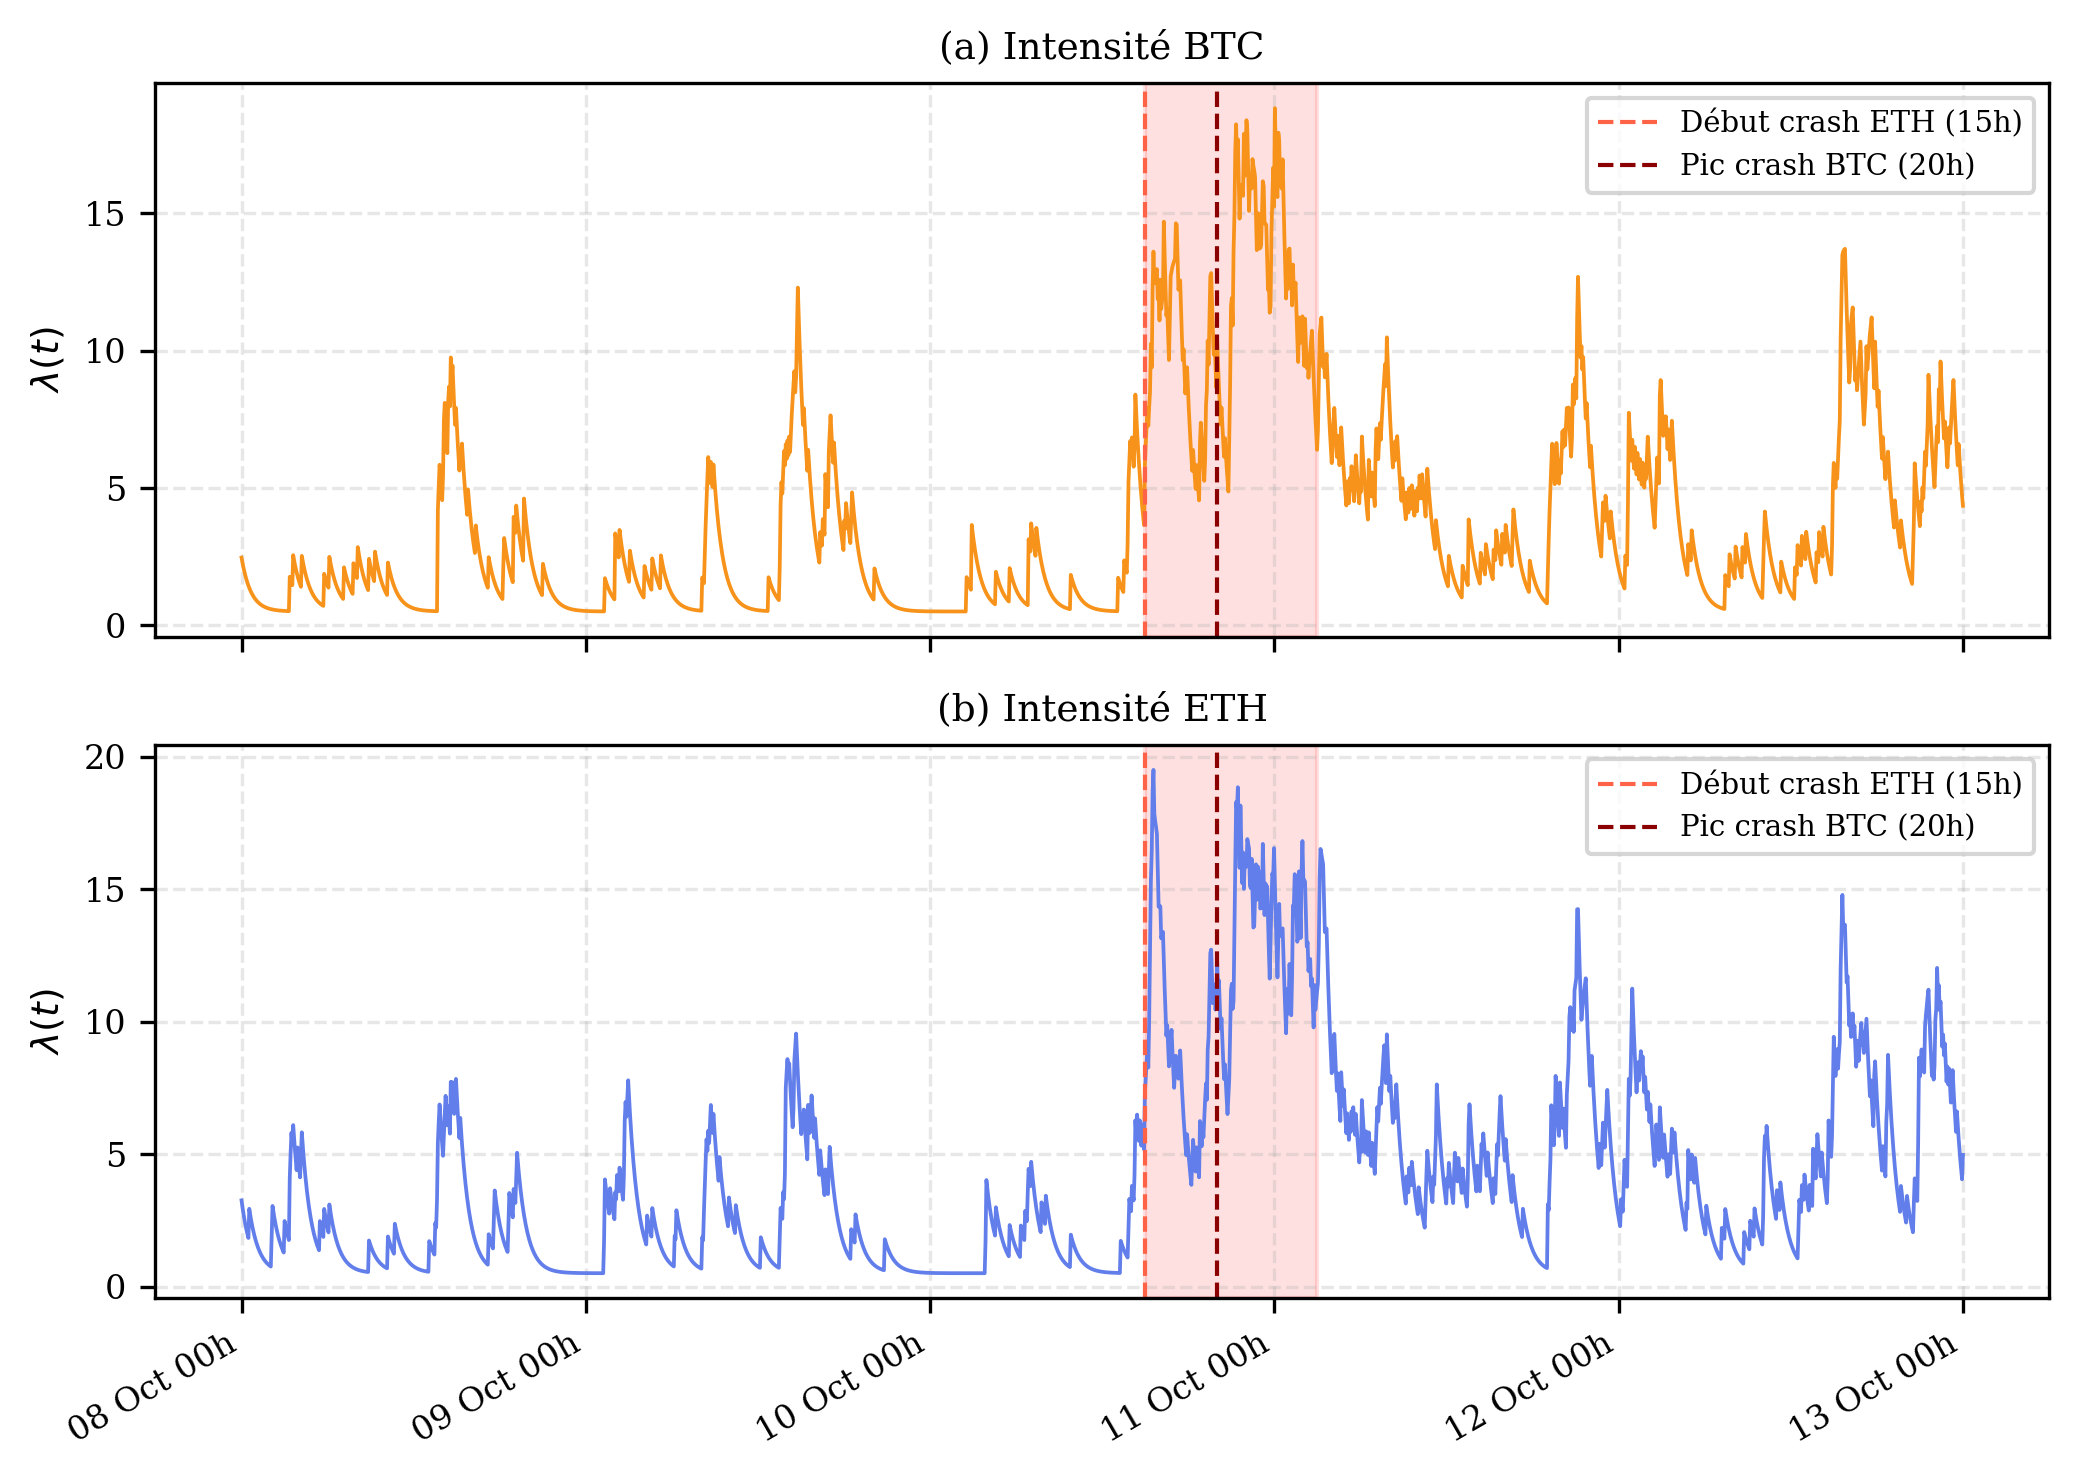

In [23]:
# ============================================================
# BLOC A — HAWKES CLASSIQUE UNIVARIÉ
# ============================================================

print("\n" + "="*50)
print("BLOC A — HAWKES CLASSIQUE UNIVARIÉ")
print("="*50)

params_uni = {}
for name, events in [("BTC", ev_btc_neg), ("ETH", ev_eth_neg)]:
    mu, alpha, beta = fit_hawkes_uni(events, T)
    n = alpha / beta
    params_uni[name] = (mu, alpha, beta, n)
    print(f"\n{name} :")
    print(f"  μ     = {mu:.6f}  événements/heure")
    print(f"  α     = {alpha:.6f}")
    print(f"  β     = {beta:.6f}")
    print(f"  n=α/β = {n:.6f}  "
          f"({'⚠ critique' if n > 0.8 else 'stable'})")
    print(f"  Durée moy. excitation = {1/beta:.3f}h "
          f"= {60/beta:.1f} min")

# ============================================================
# BLOC B — HAWKES CLASSIQUE MULTIVARIÉ
# ============================================================

print("\n" + "="*50)
print("BLOC B — HAWKES CLASSIQUE MULTIVARIÉ BTC <-> ETH")
print("="*50)

res_b = fit_hawkes_biv(ev_btc_neg, ev_eth_neg, T)
A_b   = res_b['A']
mu_b  = res_b['mu']

print(f"\nBaseline : μ_BTC={mu_b[0]:.6f}, μ_ETH={mu_b[1]:.6f}")
print(f"β = {res_b['beta']:.6f}")
print(f"\nMatrice d'adjacence :")
print(f"  BTC→BTC : {A_b[0,0]:.6f}  (auto-excitation BTC)")
print(f"  ETH→BTC : {A_b[0,1]:.6f}  ← contagion ETH→BTC")
print(f"  BTC→ETH : {A_b[1,0]:.6f}  ← contagion BTC→ETH")
print(f"  ETH→ETH : {A_b[1,1]:.6f}  (auto-excitation ETH)")

if A_b[0,1] > A_b[1,0]:
    print(f"\n✓ Contagion dominante : ETH → BTC "
          f"({A_b[0,1]:.4f} > {A_b[1,0]:.4f})")
else:
    print(f"\n✓ Contagion dominante : BTC → ETH "
          f"({A_b[1,0]:.4f} > {A_b[0,1]:.4f})")

# ============================================================
# BLOC C — 2T-POT UNIVARIÉ (Tomlinson)
# ============================================================

print("\n" + "="*50)
print("BLOC C — 2T-POT UNIVARIÉ (Tomlinson)")
print("="*50)

params_2t = {}
for name, ev_neg, ev_pos in [
    ("BTC", ev_btc_neg, ev_btc_pos),
    ("ETH", ev_eth_neg, ev_eth_pos)
]:
    res = fit_hawkes_biv(ev_neg, ev_pos, T)
    A2  = res['A']
    mu2 = res['mu']
    params_2t[name] = res
    print(f"\n{name} — 2T-POT :")
    print(f"  μ_neg={mu2[0]:.6f}  μ_pos={mu2[1]:.6f}")
    print(f"  β = {res['beta']:.6f}")
    print(f"  α(neg→neg) = {A2[0,0]:.6f}  auto-excitation pertes")
    print(f"  α(pos→neg) = {A2[0,1]:.6f}  gains → pertes")
    print(f"  α(neg→pos) = {A2[1,0]:.6f}  pertes → gains")
    print(f"  α(pos→pos) = {A2[1,1]:.6f}  auto-excitation gains")
    leverage = A2[0,0] > A2[1,1]
    print(f"  Effet levier temporel : "
          f"{'✓ OUI' if leverage else '✗ NON'} "
          f"({A2[0,0]:.4f} vs {A2[1,1]:.4f})")

# ============================================================
# BLOC D — 2T-POT MULTIVARIÉ (extension Tomlinson)
# ============================================================

print("\n" + "="*50)
print("BLOC D — 2T-POT MULTIVARIÉ ETH_neg <-> BTC_neg")
print("="*50)

res_d = fit_hawkes_biv(ev_btc_neg, ev_eth_neg, T)
A_d   = res_d['A']
print(f"\nContagion pertes ETH <-> BTC :")
print(f"  ETH_neg → BTC_neg : {A_d[0,1]:.6f}")
print(f"  BTC_neg → ETH_neg : {A_d[1,0]:.6f}")
if A_d[0,1] > A_d[1,0]:
    print(f"  ✓ ETH excite BTC plus fortement")
else:
    print(f"  ✓ BTC excite ETH plus fortement")

# ============================================================
# FIGURE — Intensité conditionnelle autour du crash
# ============================================================

def compute_intensity(events, mu, alpha, beta, t_grid):
    intensity = np.full(len(t_grid), mu)
    for ti in events:
        mask = t_grid > ti
        intensity[mask] += alpha * np.exp(
            -beta * (t_grid[mask] - ti))
    return intensity

t_start = (pd.Timestamp('2025-10-08') - t0
           ).total_seconds() / 3600
t_end   = (pd.Timestamp('2025-10-13') - t0
           ).total_seconds() / 3600
t_grid  = np.linspace(t_start, t_end, 2000)
t_axis  = [t0 + pd.Timedelta(hours=h) for h in t_grid]

mu_btc, al_btc, be_btc, _ = params_uni["BTC"]
mu_eth, al_eth, be_eth, _ = params_uni["ETH"]

lam_btc = compute_intensity(ev_btc_neg, mu_btc,
                             al_btc, be_btc, t_grid)
lam_eth = compute_intensity(ev_eth_neg, mu_eth,
                             al_eth, be_eth, t_grid)

fig, axes = plt.subplots(2, 1, figsize=(7, 5), sharex=True)

for ax, lam, color, label in [
    (axes[0], lam_btc, '#F7931A', '(a) Intensité BTC'),
    (axes[1], lam_eth, '#627EEA', '(b) Intensité ETH')
]:
    ax.plot(t_axis, lam, color=color, linewidth=0.9)
    ax.axvspan(pd.Timestamp('2025-10-10 15:00:00'),
               pd.Timestamp('2025-10-11 03:00:00'),
               alpha=0.12, color='red', zorder=0)
    ax.axvline(pd.Timestamp('2025-10-10 15:00:00'),
               color='tomato', linestyle='--',
               linewidth=1, label='Début crash ETH (15h)')
    ax.axvline(pd.Timestamp('2025-10-10 20:00:00'),
               color='darkred', linestyle='--',
               linewidth=1, label='Pic crash BTC (20h)')
    ax.set_ylabel(r'$\lambda(t)$')
    ax.set_title(label)
    ax.legend(fontsize=7)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%d %b %Hh'))
axes[1].xaxis.set_major_locator(
    mdates.DayLocator(interval=1))
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig_hawkes_intensity.pdf', bbox_inches='tight')
plt.show()

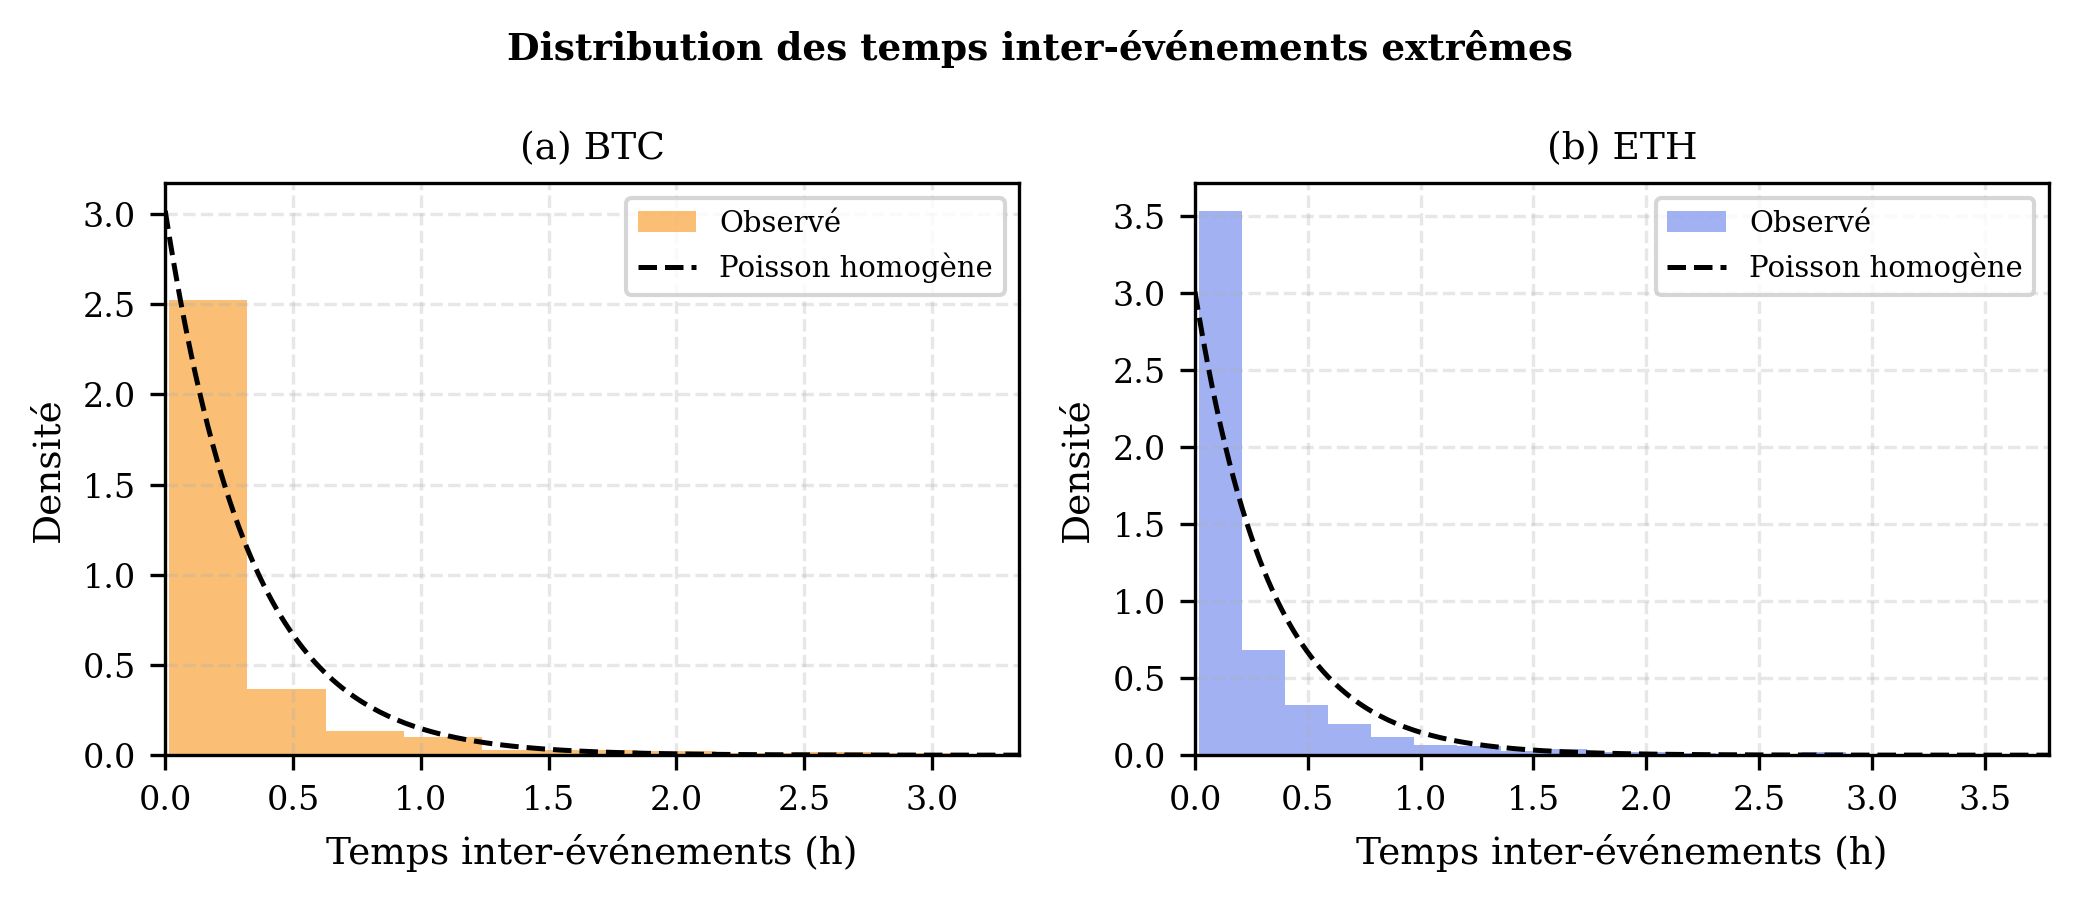

Figure 1 sauvegardée ✓
Calcul résidus BTC...
Calcul résidus ETH...


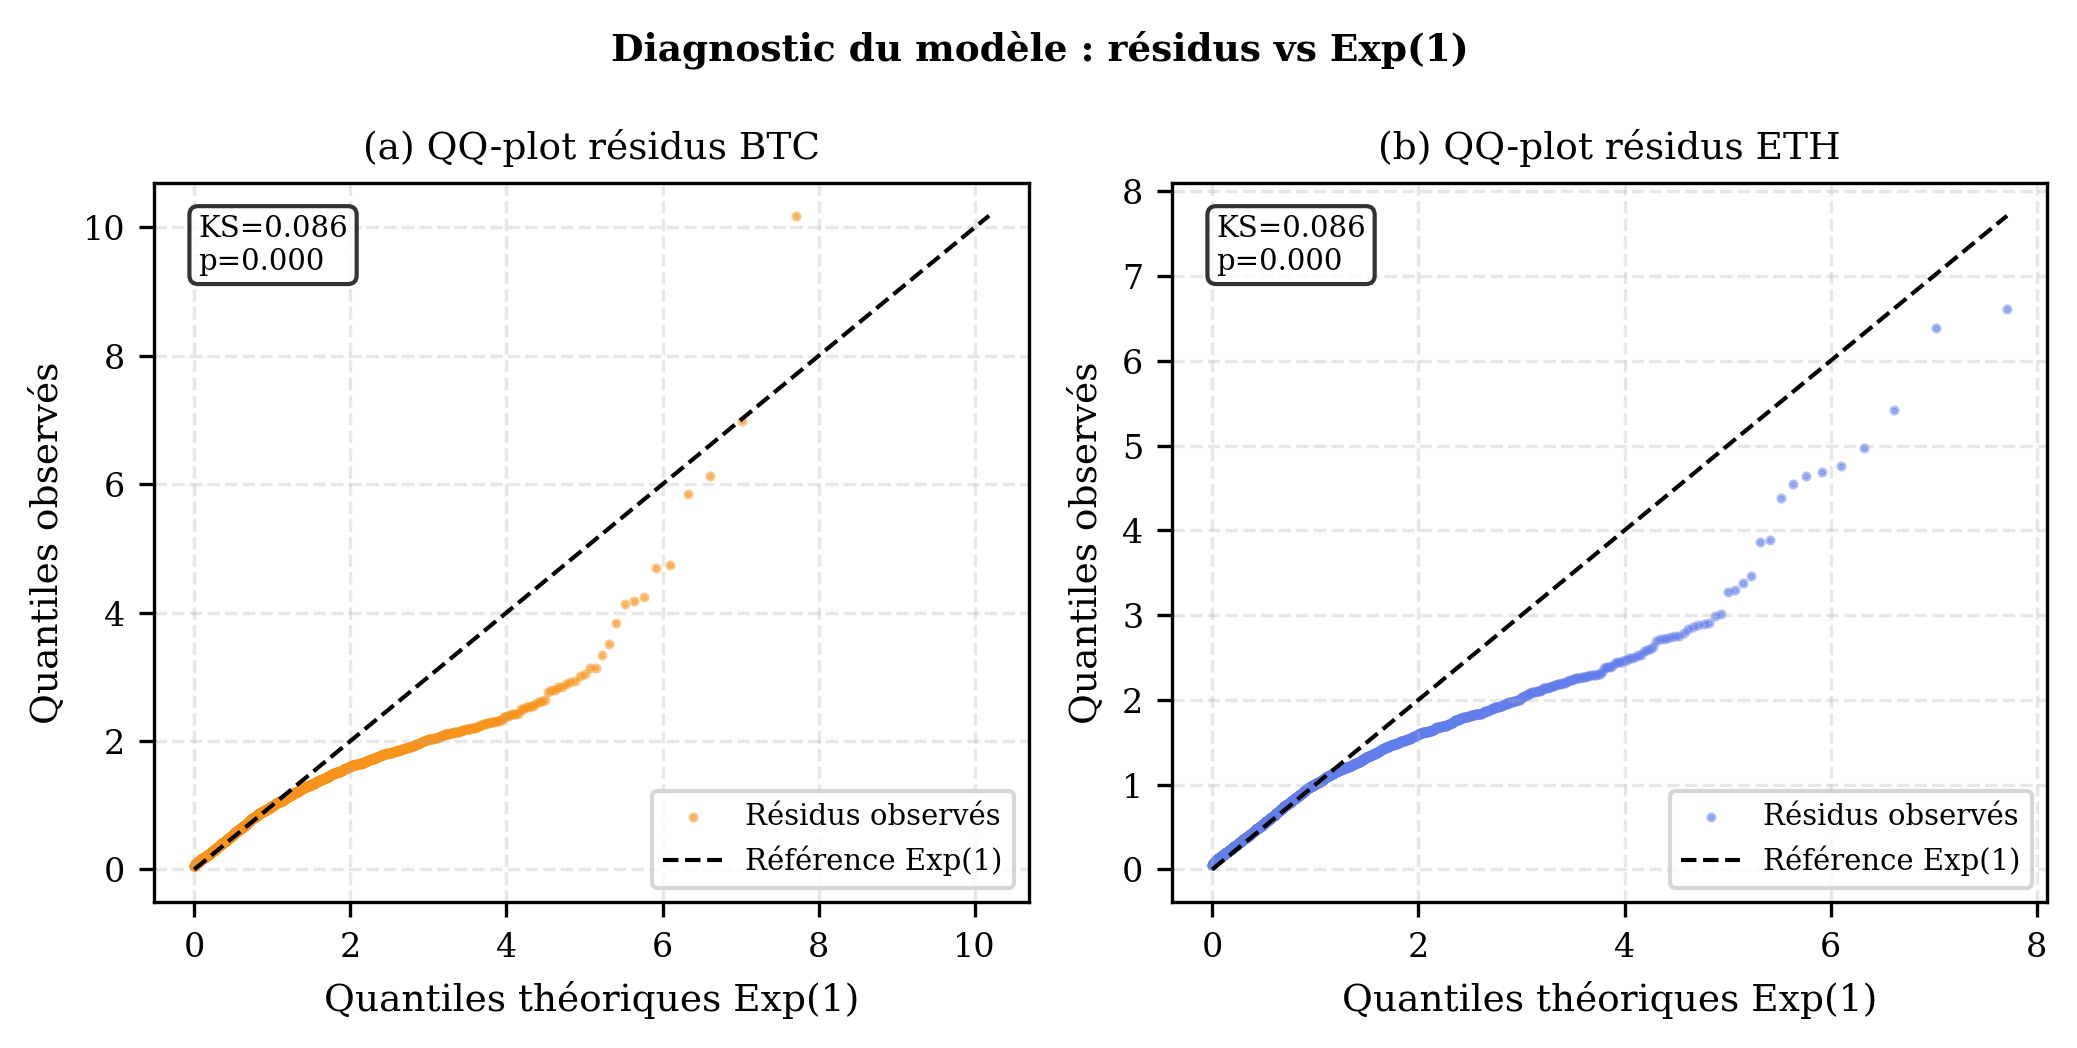

Figure 2 sauvegardée ✓


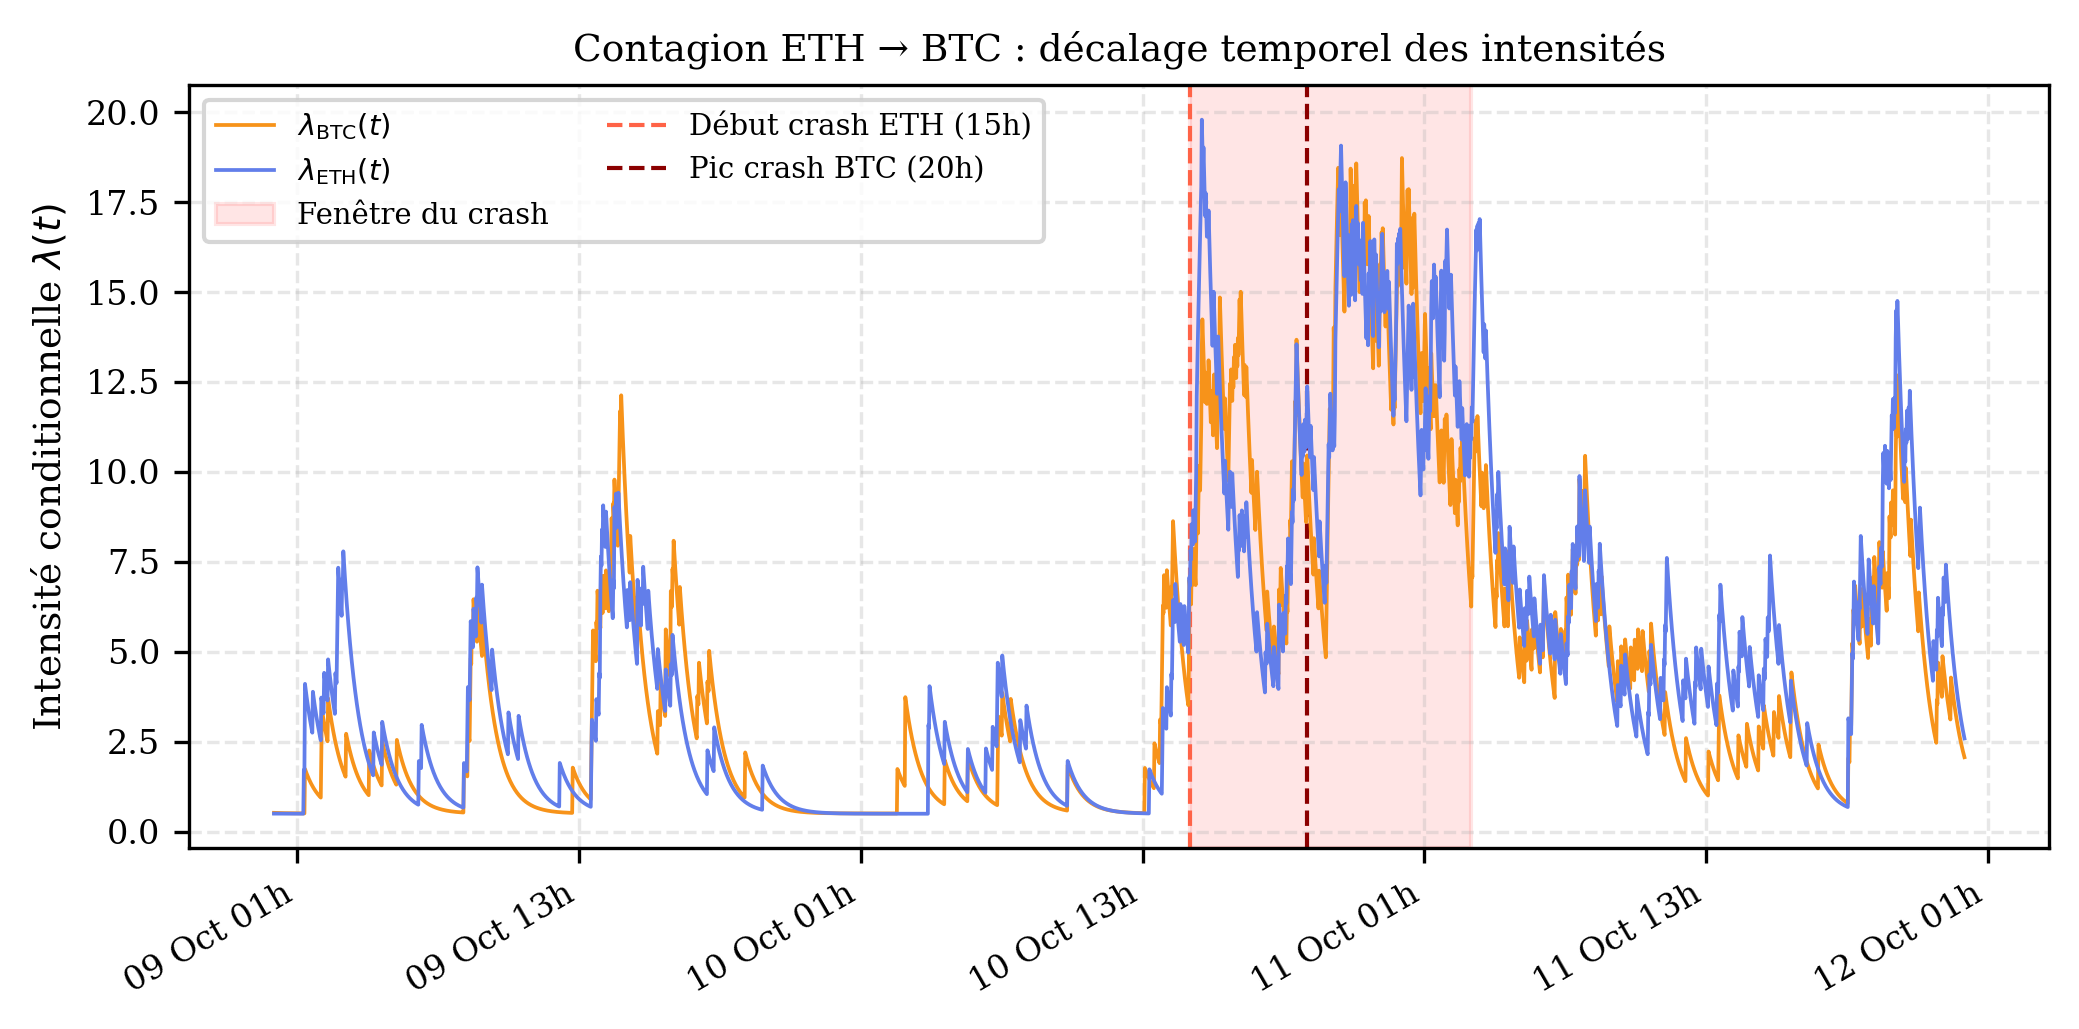

Figure 3 sauvegardée ✓


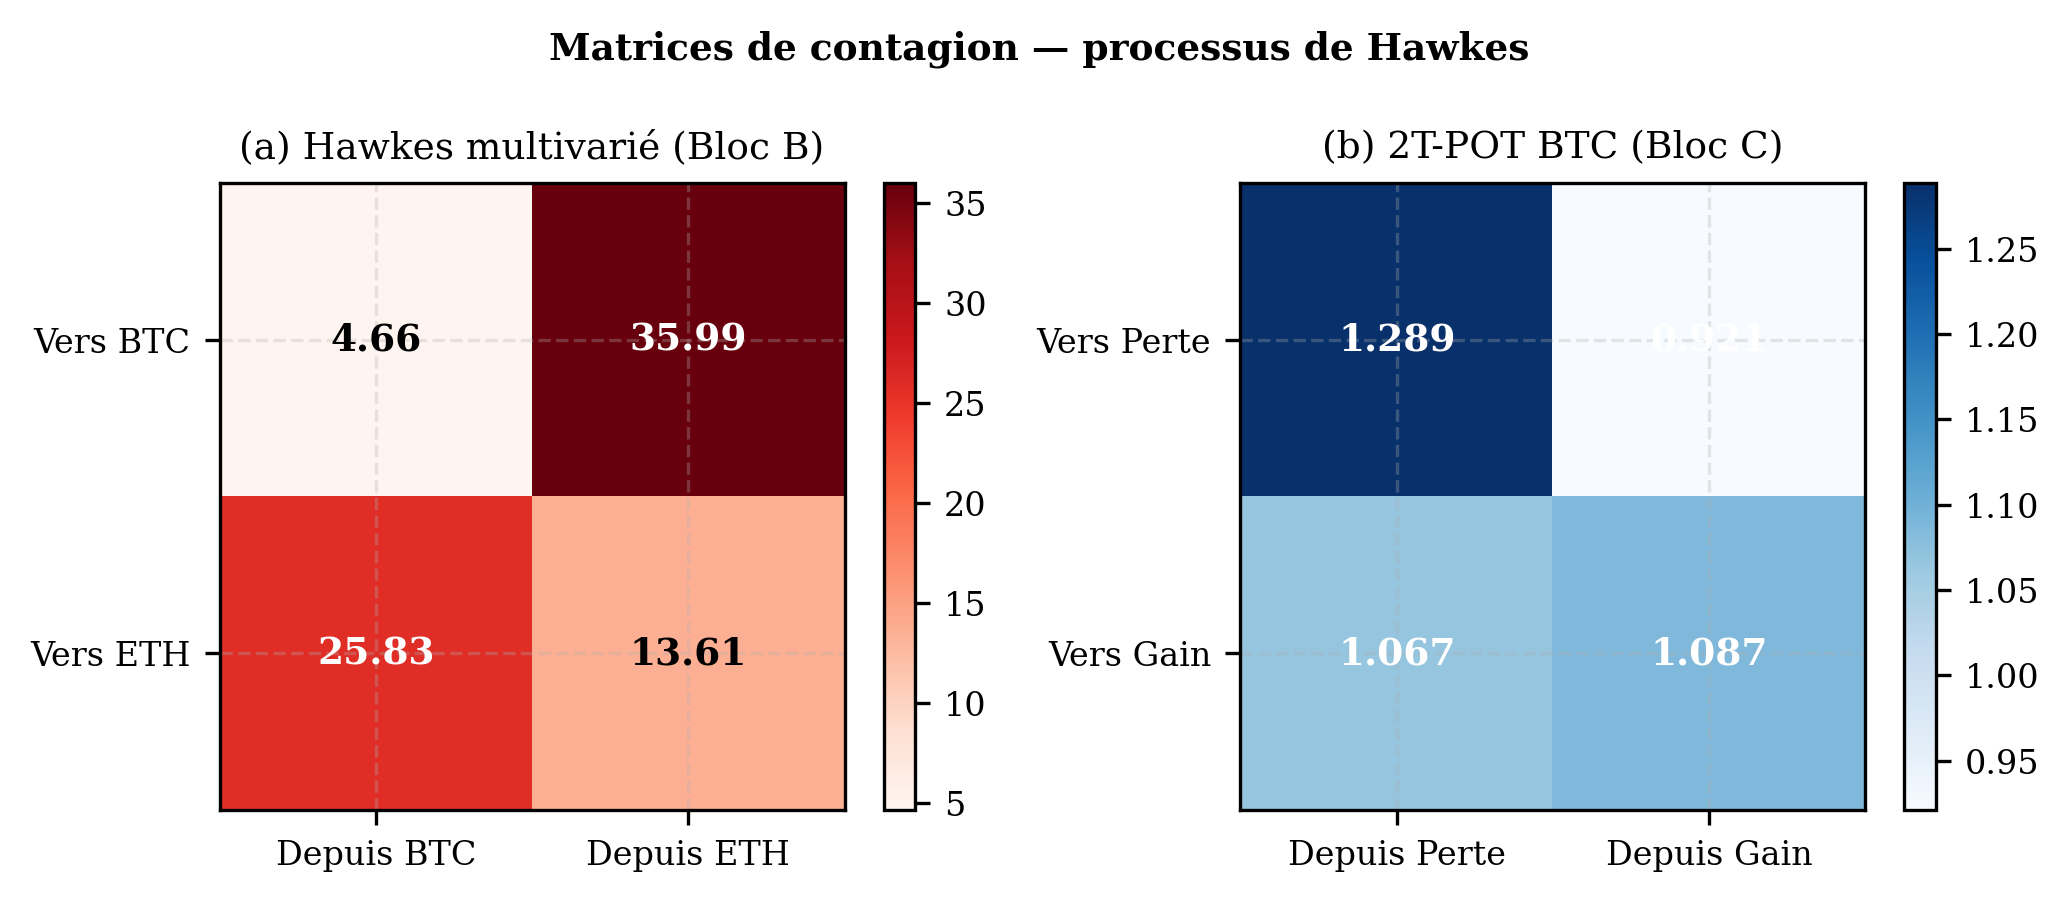

Figure 4 sauvegardée ✓


In [24]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 9,
    'axes.labelsize': 9,
    'axes.titlesize': 9,
    'legend.fontsize': 7,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

# Récupérer paramètres univariés déjà estimés
mu_btc, al_btc, be_btc, _ = params_uni["BTC"]
mu_eth, al_eth, be_eth, _ = params_uni["ETH"]

# ============================================================
# FIGURE 1 — Histogramme des temps inter-événements
# ============================================================

iat_btc = np.diff(ev_btc_neg)
iat_eth = np.diff(ev_eth_neg)

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

for i, (ax, iat, color, name) in enumerate([
    (axes[0], iat_btc, '#F7931A', 'BTC'),
    (axes[1], iat_eth, '#627EEA', 'ETH')
]):
    rate = 1 / np.mean(iat)
    xlim = np.percentile(iat, 99)
    x    = np.linspace(0, xlim, 200)

    ax.hist(iat, bins=60, density=True,
            color=color, alpha=0.6, label='Observé')
    ax.plot(x, rate * np.exp(-rate * x),
            color='black', linewidth=1.2,
            linestyle='--', label='Poisson homogène')
    ax.set_xlabel('Temps inter-événements (h)')
    ax.set_ylabel('Densité')
    ax.set_title(f'({"ab"[i]}) {name}')
    ax.set_xlim(0, xlim)
    ax.legend()

plt.suptitle('Distribution des temps inter-événements extrêmes',
             fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_hawkes_interarrival.pdf', bbox_inches='tight')
plt.show()
print("Figure 1 sauvegardée ✓")

# ============================================================
# FIGURE 2 — Résidus QQ-plot (test qualité du fit)
# ============================================================

def compute_compensator_fast(events, mu, alpha, beta):
    """Calcule les résidus O(n) — si Exp(1) : bon fit."""
    n = len(events)
    residuals = np.zeros(n - 1)
    R = 0.0
    for i in range(1, n):
        dt = events[i] - events[i-1]
        R  = np.exp(-beta * dt) * (R + 1)
        residuals[i-1] = (mu * dt +
            (alpha / beta) * (1 - np.exp(-beta * dt)) * (R + 1))
    return residuals

print("Calcul résidus BTC...")
res_btc = compute_compensator_fast(ev_btc_neg, mu_btc,
                                    al_btc, be_btc)
print("Calcul résidus ETH...")
res_eth = compute_compensator_fast(ev_eth_neg, mu_eth,
                                    al_eth, be_eth)

fig, axes = plt.subplots(1, 2, figsize=(7, 3.5))

for i, (ax, residuals, color, name) in enumerate([
    (axes[0], res_btc, '#F7931A', 'BTC'),
    (axes[1], res_eth, '#627EEA', 'ETH')
]):
    sorted_res  = np.sort(residuals)
    n_res       = len(sorted_res)
    theoretical = stats.expon.ppf(
        np.arange(1, n_res + 1) / (n_res + 1))

    ax.scatter(theoretical, sorted_res,
               color=color, s=2, alpha=0.5,
               label='Résidus observés')
    max_val = max(theoretical.max(), sorted_res.max())
    ax.plot([0, max_val], [0, max_val],
            color='black', linewidth=1,
            linestyle='--', label='Référence Exp(1)')

    # Test KS
    ks_stat, ks_pval = stats.kstest(residuals, 'expon')
    ax.text(0.05, 0.88,
            f'KS={ks_stat:.3f}\np={ks_pval:.3f}',
            transform=ax.transAxes, fontsize=7,
            bbox=dict(boxstyle='round',
                      facecolor='white', alpha=0.8))

    ax.set_xlabel('Quantiles théoriques Exp(1)')
    ax.set_ylabel('Quantiles observés')
    ax.set_title(f'({"ab"[i]}) QQ-plot résidus {name}')
    ax.legend()

plt.suptitle('Diagnostic du modèle : résidus vs Exp(1)',
             fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_hawkes_residuals.pdf', bbox_inches='tight')
plt.show()
print("Figure 2 sauvegardée ✓")

# ============================================================
# FIGURE 3 — Intensités BTC vs ETH superposées
# ============================================================

t_start = (pd.Timestamp('2025-10-09') - t0
           ).total_seconds() / 3600
t_end   = (pd.Timestamp('2025-10-12') - t0
           ).total_seconds() / 3600
t_grid  = np.linspace(t_start, t_end, 3000)
t_axis  = [t0 + pd.Timedelta(hours=h) for h in t_grid]

lam_btc = compute_intensity(ev_btc_neg, mu_btc,
                             al_btc, be_btc, t_grid)
lam_eth = compute_intensity(ev_eth_neg, mu_eth,
                             al_eth, be_eth, t_grid)

fig, ax = plt.subplots(figsize=(7, 3.5))

ax.plot(t_axis, lam_btc, color='#F7931A', linewidth=0.9,
        label=r'$\lambda_{\mathrm{BTC}}(t)$', zorder=3)
ax.plot(t_axis, lam_eth, color='#627EEA', linewidth=0.9,
        label=r'$\lambda_{\mathrm{ETH}}(t)$', zorder=3)

ax.axvspan(pd.Timestamp('2025-10-10 15:00:00'),
           pd.Timestamp('2025-10-11 03:00:00'),
           alpha=0.10, color='red', zorder=0,
           label='Fenêtre du crash')
ax.axvline(pd.Timestamp('2025-10-10 15:00:00'),
           color='tomato', linestyle='--',
           linewidth=1, label='Début crash ETH (15h)')
ax.axvline(pd.Timestamp('2025-10-10 20:00:00'),
           color='darkred', linestyle='--',
           linewidth=1, label='Pic crash BTC (20h)')

ax.set_ylabel(r'Intensité conditionnelle $\lambda(t)$')
ax.set_title('Contagion ETH → BTC : '
             'décalage temporel des intensités')
ax.legend(fontsize=7, ncol=2)
ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%d %b %Hh'))
ax.xaxis.set_major_locator(
    mdates.HourLocator(interval=12))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig_hawkes_contagion.pdf', bbox_inches='tight')
plt.show()
print("Figure 3 sauvegardée ✓")

# ============================================================
# FIGURE 4 — Heatmap matrices de contagion
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Bloc B — Hawkes classique multivarié
im1 = axes[0].imshow(A_b, cmap='Reds', aspect='auto')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Depuis BTC', 'Depuis ETH'])
axes[0].set_yticklabels(['Vers BTC', 'Vers ETH'])
axes[0].set_title('(a) Hawkes multivarié (Bloc B)')
plt.colorbar(im1, ax=axes[0])
for i in range(2):
    for j in range(2):
        val   = A_b[i, j]
        color = 'white' if val > A_b.max() / 2 else 'black'
        axes[0].text(j, i, f'{val:.2f}',
                     ha='center', va='center',
                     fontsize=9, fontweight='bold',
                     color=color)

# Bloc C — 2T-POT BTC
A_2t = params_2t["BTC"]['A']
im2  = axes[1].imshow(A_2t, cmap='Blues', aspect='auto')
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Depuis Perte', 'Depuis Gain'])
axes[1].set_yticklabels(['Vers Perte', 'Vers Gain'])
axes[1].set_title('(b) 2T-POT BTC (Bloc C)')
plt.colorbar(im2, ax=axes[1])
for i in range(2):
    for j in range(2):
        val   = A_2t[i, j]
        color = 'white' if val > A_2t.max() / 2 else 'black'
        axes[1].text(j, i, f'{val:.3f}',
                     ha='center', va='center',
                     fontsize=9, fontweight='bold',
                     color=color)

plt.suptitle('Matrices de contagion — processus de Hawkes',
             fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_hawkes_heatmap.pdf', bbox_inches='tight')
plt.show()
print("Figure 4 sauvegardée ✓")

Calcul intensités 2T-POT BTC...
Calcul intensités 2T-POT ETH...


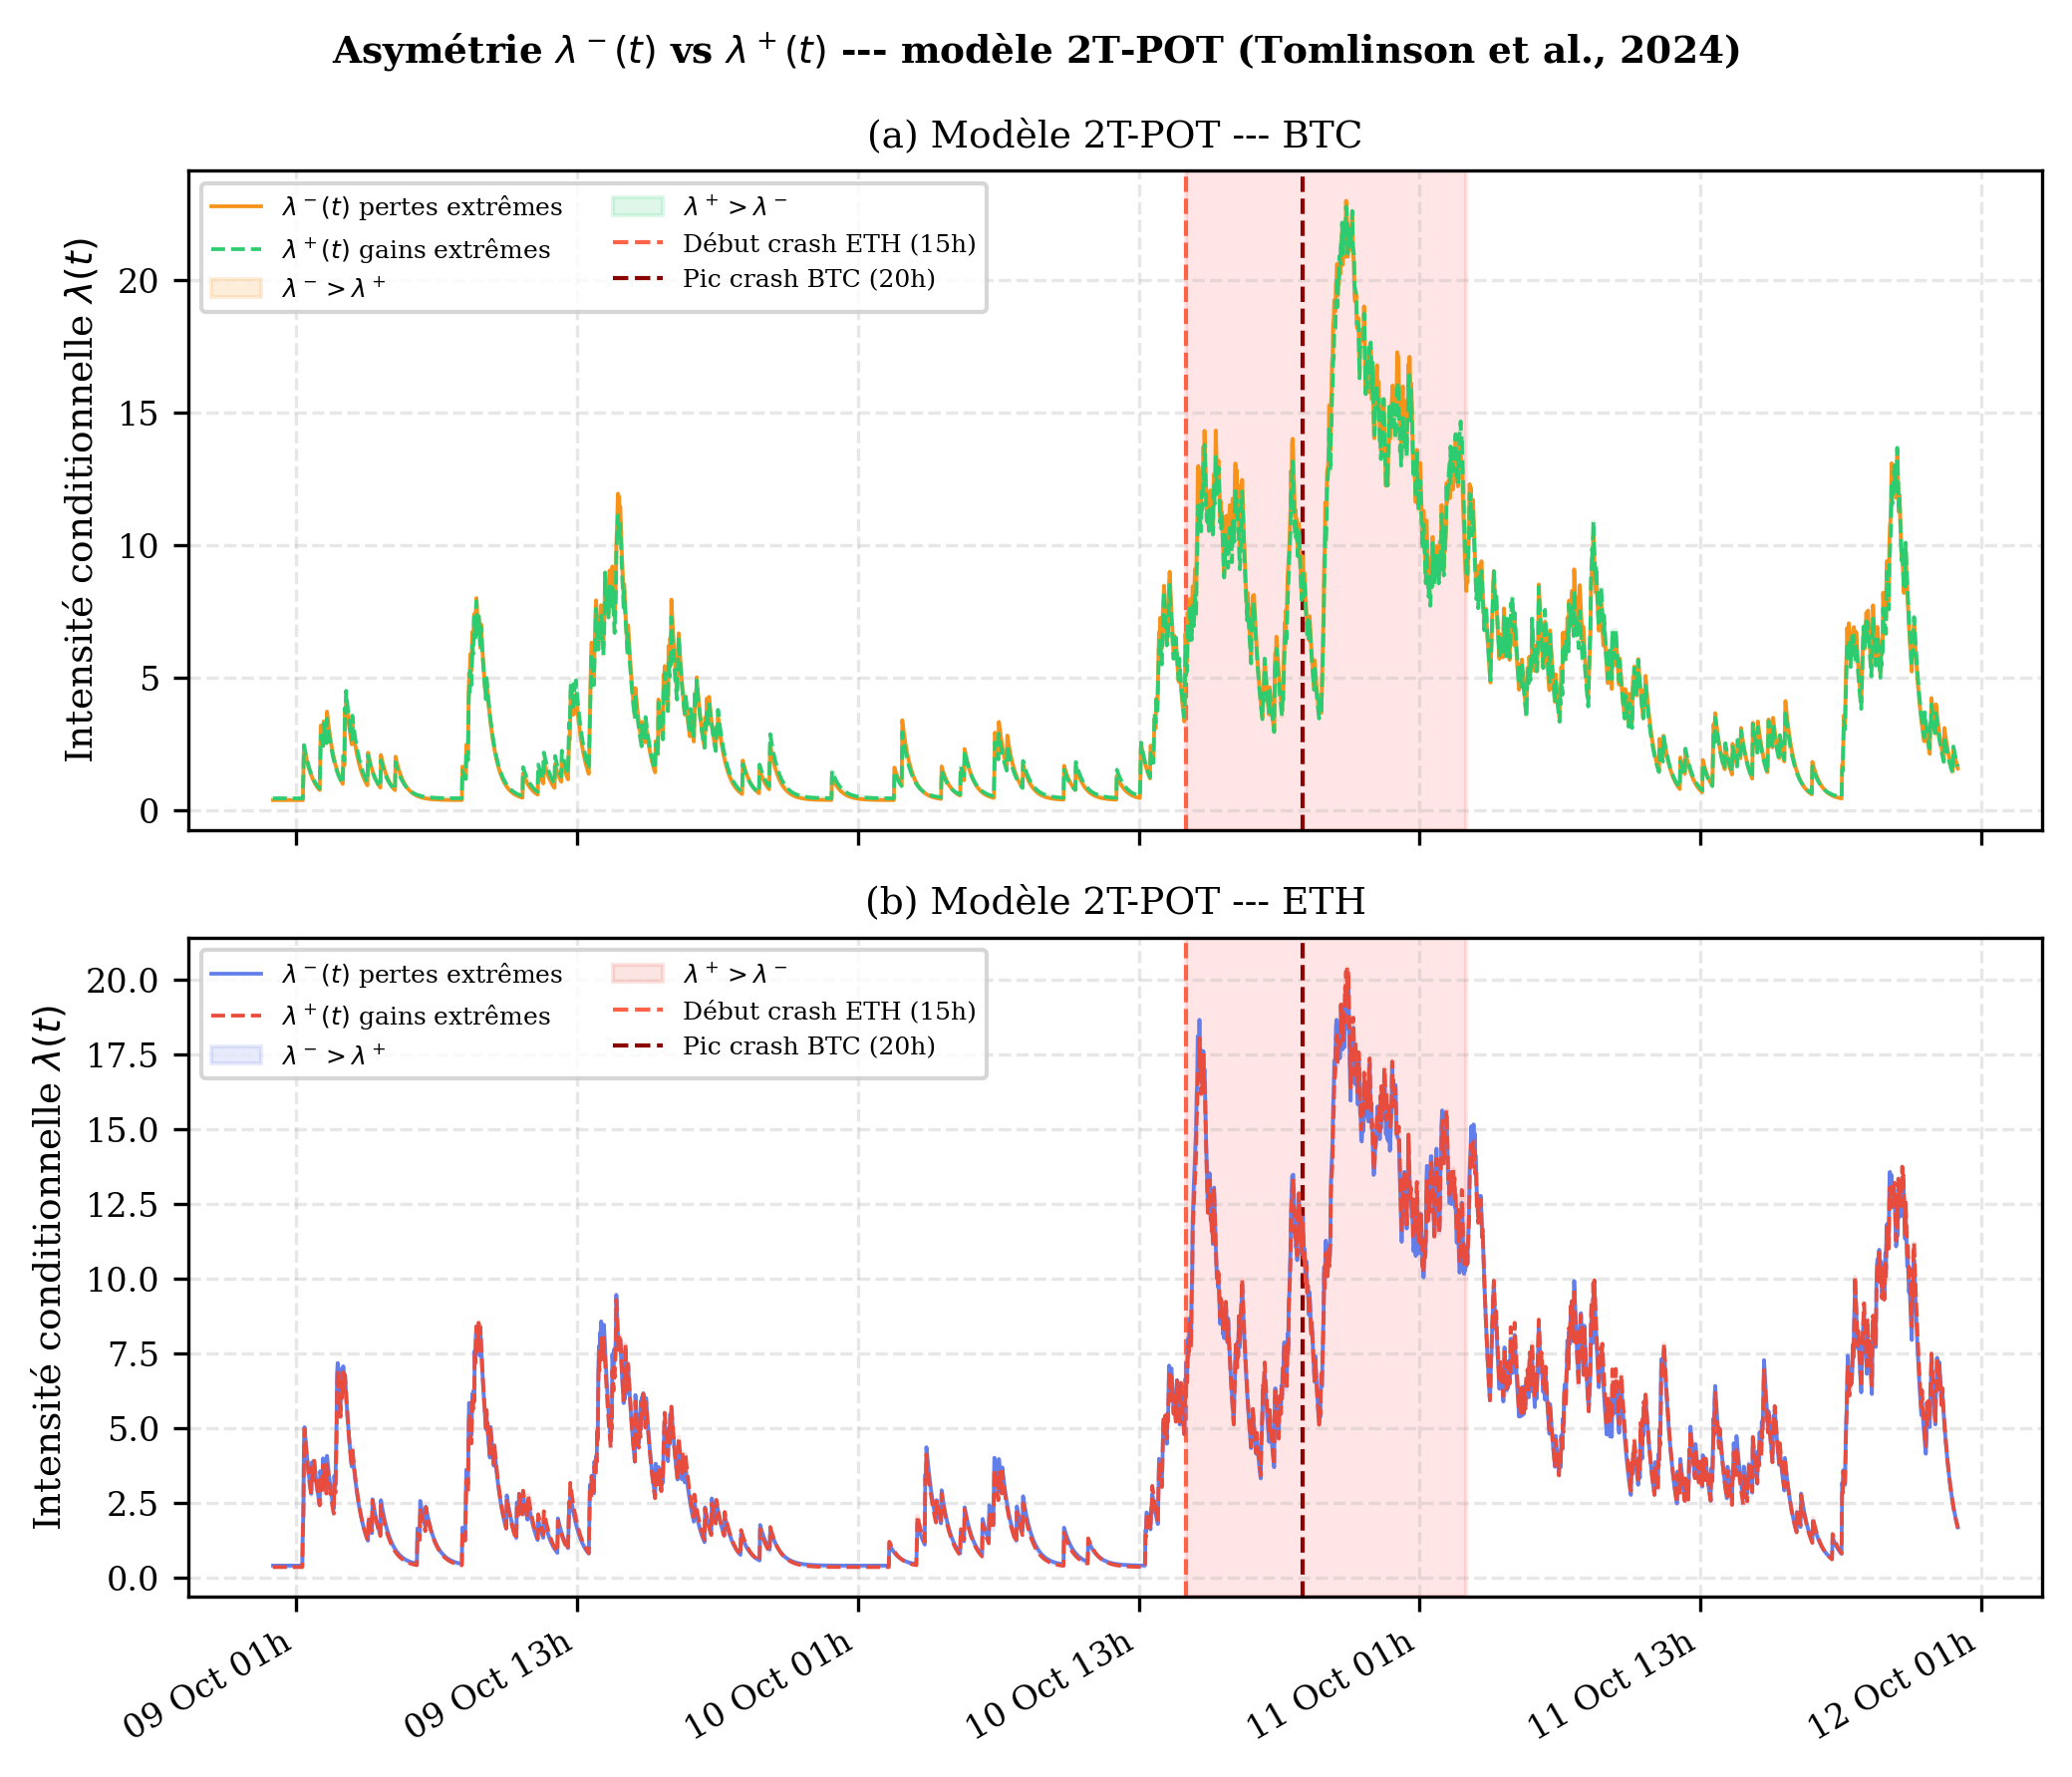

Figure 2T-POT sauvegardée ✓


In [25]:
# ============================================================
# FIGURE — Intensités 2T-POT : λ⁻(t) vs λ⁺(t)
# ============================================================
# Utilise les paramètres du Bloc C (params_2t)

def compute_intensity_2tpot(ev_neg, ev_pos,
                             mu_neg, mu_pos,
                             a_nn, a_pn, a_np, a_pp,
                             beta, t_grid):
    """
    Calcule λ⁻(t) et λ⁺(t) du modèle 2T-POT.
    a_nn = neg→neg, a_pn = pos→neg
    a_np = neg→pos, a_pp = pos→pos
    """
    lam_neg = np.full(len(t_grid), mu_neg)
    lam_pos = np.full(len(t_grid), mu_pos)

    # Contribution des événements négatifs
    for ti in ev_neg:
        mask = t_grid > ti
        dt   = t_grid[mask] - ti
        lam_neg[mask] += a_nn * np.exp(-beta * dt)
        lam_pos[mask] += a_np * np.exp(-beta * dt)

    # Contribution des événements positifs
    for ti in ev_pos:
        mask = t_grid > ti
        dt   = t_grid[mask] - ti
        lam_neg[mask] += a_pn * np.exp(-beta * dt)
        lam_pos[mask] += a_pp * np.exp(-beta * dt)

    return lam_neg, lam_pos

# Fenêtre autour du crash
t_start = (pd.Timestamp('2025-10-09') - t0
           ).total_seconds() / 3600
t_end   = (pd.Timestamp('2025-10-12') - t0
           ).total_seconds() / 3600
t_grid  = np.linspace(t_start, t_end, 3000)
t_axis  = [t0 + pd.Timedelta(hours=h) for h in t_grid]

# ---- Paramètres Bloc C ----
# BTC
A_btc  = params_2t["BTC"]['A']
mu_btc = params_2t["BTC"]['mu']
be_btc = params_2t["BTC"]['beta']

a_nn_btc = A_btc[0, 0]  # neg → neg
a_pn_btc = A_btc[0, 1]  # pos → neg
a_np_btc = A_btc[1, 0]  # neg → pos
a_pp_btc = A_btc[1, 1]  # pos → pos

# ETH
A_eth  = params_2t["ETH"]['A']
mu_eth = params_2t["ETH"]['mu']
be_eth = params_2t["ETH"]['beta']

a_nn_eth = A_eth[0, 0]
a_pn_eth = A_eth[0, 1]
a_np_eth = A_eth[1, 0]
a_pp_eth = A_eth[1, 1]

# ---- Calcul des intensités ----
print("Calcul intensités 2T-POT BTC...")
lam_btc_neg, lam_btc_pos = compute_intensity_2tpot(
    ev_btc_neg, ev_btc_pos,
    mu_btc[0], mu_btc[1],
    a_nn_btc, a_pn_btc, a_np_btc, a_pp_btc,
    be_btc, t_grid)

print("Calcul intensités 2T-POT ETH...")
lam_eth_neg, lam_eth_pos = compute_intensity_2tpot(
    ev_eth_neg, ev_eth_pos,
    mu_eth[0], mu_eth[1],
    a_nn_eth, a_pn_eth, a_np_eth, a_pp_eth,
    be_eth, t_grid)

# ---- Figure ----
fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

crash_start = pd.Timestamp('2025-10-10 15:00:00')
crash_peak  = pd.Timestamp('2025-10-10 20:00:00')
crash_end   = pd.Timestamp('2025-10-11 03:00:00')

for ax, lam_neg, lam_pos, color_neg, color_pos, name in [
    (axes[0], lam_btc_neg, lam_btc_pos,
     '#F7931A', '#2ECC71', 'BTC'),
    (axes[1], lam_eth_neg, lam_eth_pos,
     '#627EEA', '#E74C3C', 'ETH')
]:
    # Zone crash
    ax.axvspan(crash_start, crash_end,
               alpha=0.10, color='red', zorder=0)

    # Intensités
    ax.plot(t_axis, lam_neg, color=color_neg,
            linewidth=0.9, zorder=3,
            label=r'$\lambda^-(t)$ pertes extrêmes')
    ax.plot(t_axis, lam_pos, color=color_pos,
            linewidth=0.9, zorder=3,
            linestyle='--',
            label=r'$\lambda^+(t)$ gains extrêmes')

    # Zone entre les deux courbes
    ax.fill_between(t_axis, lam_neg, lam_pos,
                    where=(lam_neg > lam_pos),
                    alpha=0.15, color=color_neg,
                    label=r'$\lambda^- > \lambda^+$')
    ax.fill_between(t_axis, lam_neg, lam_pos,
                    where=(lam_pos >= lam_neg),
                    alpha=0.15, color=color_pos,
                    label=r'$\lambda^+ > \lambda^-$')

    # Lignes crash
    ax.axvline(crash_start, color='tomato',
               linestyle='--', linewidth=1,
               label='Début crash ETH (15h)')
    ax.axvline(crash_peak, color='darkred',
               linestyle='--', linewidth=1,
               label='Pic crash BTC (20h)')

    ax.set_ylabel(r'Intensité conditionnelle $\lambda(t)$')
    ax.set_title(f'({["a","b"][["BTC","ETH"].index(name)]}) '
                 f'Modèle 2T-POT --- {name}')
    ax.legend(fontsize=6, ncol=2)

axes[1].xaxis.set_major_formatter(
    mdates.DateFormatter('%d %b %Hh'))
axes[1].xaxis.set_major_locator(
    mdates.HourLocator(interval=12))
plt.setp(axes[1].get_xticklabels(), rotation=30, ha='right')

plt.suptitle(
    r'Asymétrie $\lambda^-(t)$ vs $\lambda^+(t)$ '
    r'--- modèle 2T-POT (Tomlinson et al., 2024)',
    fontsize=9, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_hawkes_2tpot.pdf', bbox_inches='tight')
plt.show()
print("Figure 2T-POT sauvegardée ✓")

### Bloc B et D avec paramètres fixé (beta)

In [26]:
def neg_ll_bivariate_fixed_beta(params, ev1, ev2, T, beta):
    """
    Log-vraisemblance négative — Hawkes bivarié
    avec beta FIXÉ (évite l'instabilité numérique).
    """
    mu1, mu2, a11, a12, a21, a22 = params
    if any(p <= 0 for p in params):
        return np.inf
    if (a11 + a12) / beta >= 1 or (a21 + a22) / beta >= 1:
        return np.inf

    # Fusionner et trier les deux flux
    all_ev = np.concatenate([ev1, ev2])
    labels = np.concatenate([np.zeros(len(ev1)),
                              np.ones(len(ev2))])
    order  = np.argsort(all_ev)
    all_ev = all_ev[order]
    labels = labels[order]

    # Terme intégrale
    integral  = (mu1 + mu2) * T
    integral += (a11 + a21) / beta * np.sum(
        1 - np.exp(-beta * (T - ev1)))
    integral += (a12 + a22) / beta * np.sum(
        1 - np.exp(-beta * (T - ev2)))

    # Terme log-intensités avec récursion
    R1, R2  = 0.0, 0.0
    prev_t  = 0.0
    log_sum = 0.0

    for t, lab in zip(all_ev, labels):
        dt  = t - prev_t
        R1 *= np.exp(-beta * dt)
        R2 *= np.exp(-beta * dt)

        lam1 = max(mu1 + a11 * R1 + a12 * R2, 1e-10)
        lam2 = max(mu2 + a21 * R1 + a22 * R2, 1e-10)

        if lab == 0:
            log_sum += np.log(lam1)
            R1 += 1
        else:
            log_sum += np.log(lam2)
            R2 += 1
        prev_t = t

    return integral - log_sum


def fit_hawkes_biv_fixed_beta(ev1, ev2, T,
                               beta_fixed,
                               n_starts=15):
    """
    Estimation MLE Hawkes bivarié avec beta fixé.
    Plus stable numériquement.
    """
    best_res, best_val = None, np.inf
    np.random.seed(42)

    for _ in range(n_starts):
        # 6 paramètres seulement (beta fixé)
        p0 = np.random.uniform(0.001, 0.3, 6)
        res = minimize(
            neg_ll_bivariate_fixed_beta,
            x0=p0,
            args=(ev1, ev2, T, beta_fixed),
            method='L-BFGS-B',
            bounds=[(1e-6, None)] * 6
        )
        if res.success and res.fun < best_val:
            best_val = res.fun
            best_res = res

    mu1, mu2, a11, a12, a21, a22 = best_res.x
    return {
        'mu'  : [mu1, mu2],
        'A'   : np.array([[a11, a12], [a21, a22]]),
        'beta': beta_fixed
    }


# ============================================================
# Beta fixé = moyenne des betas univariés stables (Bloc A)
# ============================================================

mu_btc_uni, al_btc_uni, be_btc_uni, _ = params_uni["BTC"]
mu_eth_uni, al_eth_uni, be_eth_uni, _ = params_uni["ETH"]

beta_fixed = (be_btc_uni + be_eth_uni) / 2
print(f"β fixé = {beta_fixed:.6f}  "
      f"(moyenne Bloc A : {be_btc_uni:.4f} et "
      f"{be_eth_uni:.4f})")

# ============================================================
# BLOC B bis — Multivarié avec beta fixé
# ============================================================

print("\n" + "="*50)
print("BLOC B bis — MULTIVARIÉ beta fixé")
print("="*50)

res_b2 = fit_hawkes_biv_fixed_beta(
    ev_btc_neg, ev_eth_neg, T, beta_fixed)
A_b2   = res_b2['A']
mu_b2  = res_b2['mu']

print(f"\nβ fixé = {beta_fixed:.6f}")
print(f"Baseline : μ_BTC={mu_b2[0]:.6f}, "
      f"μ_ETH={mu_b2[1]:.6f}")
print(f"\nMatrice d'adjacence :")
print(f"  BTC→BTC : {A_b2[0,0]:.6f}  (auto-excitation BTC)")
print(f"  ETH→BTC : {A_b2[0,1]:.6f}  ← contagion ETH→BTC")
print(f"  BTC→ETH : {A_b2[1,0]:.6f}  ← contagion BTC→ETH")
print(f"  ETH→ETH : {A_b2[1,1]:.6f}  (auto-excitation ETH)")

if A_b2[0,1] > A_b2[1,0]:
    print(f"\n✓ Contagion dominante : ETH → BTC "
          f"({A_b2[0,1]:.4f} > {A_b2[1,0]:.4f})")
else:
    print(f"\n✓ Contagion dominante : BTC → ETH "
          f"({A_b2[1,0]:.4f} > {A_b2[0,1]:.4f})")

# ============================================================
# BLOC C bis — 2T-POT avec beta fixé
# ============================================================

print("\n" + "="*50)
print("BLOC C bis — 2T-POT beta fixé")
print("="*50)

params_2t_fixed = {}
for name, ev_neg, ev_pos in [
    ("BTC", ev_btc_neg, ev_btc_pos),
    ("ETH", ev_eth_neg, ev_eth_pos)
]:
    res = fit_hawkes_biv_fixed_beta(
        ev_neg, ev_pos, T, beta_fixed)
    A2  = res['A']
    mu2 = res['mu']
    params_2t_fixed[name] = res

    print(f"\n{name} — 2T-POT (β fixé) :")
    print(f"  μ_neg={mu2[0]:.6f}  μ_pos={mu2[1]:.6f}")
    print(f"  α(neg→neg) = {A2[0,0]:.6f}")
    print(f"  α(pos→neg) = {A2[0,1]:.6f}")
    print(f"  α(neg→pos) = {A2[1,0]:.6f}")
    print(f"  α(pos→pos) = {A2[1,1]:.6f}")
    leverage = A2[0,0] > A2[1,1]
    print(f"  Effet levier : "
          f"{'✓ OUI' if leverage else '✗ NON'} "
          f"({A2[0,0]:.4f} vs {A2[1,1]:.4f})")

# ============================================================
# BLOC D bis — 2T-POT multivarié avec beta fixé
# ============================================================

print("\n" + "="*50)
print("BLOC D bis — 2T-POT MULTIVARIÉ beta fixé")
print("="*50)

res_d2 = fit_hawkes_biv_fixed_beta(
    ev_btc_neg, ev_eth_neg, T, beta_fixed)
A_d2   = res_d2['A']

print(f"\nContagion pertes ETH <-> BTC :")
print(f"  ETH_neg → BTC_neg : {A_d2[0,1]:.6f}")
print(f"  BTC_neg → ETH_neg : {A_d2[1,0]:.6f}")
if A_d2[0,1] > A_d2[1,0]:
    print(f"  ✓ ETH excite BTC plus fortement")
else:
    print(f"  ✓ BTC excite ETH plus fortement")

# ============================================================
# COMPARAISON — Bloc B original vs Bloc B bis
# ============================================================
# Remplacez le bloc COMPARAISON par :
print("\n" + "="*50)
print("COMPARAISON B original vs B bis")
print("="*50)
print(f"\n{'':20s} {'B original':15s} {'B bis (β fixé)':15s}")
print(f"{'β':20s} {61.49:15.4f} {beta_fixed:15.4f}")
print(f"{'ETH→BTC':20s} {A_b[0,1]:15.4f} {A_b2[0,1]:15.4f}")
print(f"{'BTC→ETH':20s} {A_b[1,0]:15.4f} {A_b2[1,0]:15.4f}")
print(f"{'BTC→BTC':20s} {A_b[0,0]:15.4f} {A_b2[0,0]:15.4f}")
print(f"{'ETH→ETH':20s} {A_b[1,1]:15.4f} {A_b2[1,1]:15.4f}")
print(f"\nContagion ETH→BTC dominante dans les deux cas : "
      f"{'✓' if A_b2[0,1] > A_b2[1,0] else '✗'}")

β fixé = 1.521155  (moyenne Bloc A : 1.5320 et 1.5103)

BLOC B bis — MULTIVARIÉ beta fixé

β fixé = 1.521155
Baseline : μ_BTC=0.286203, μ_ETH=0.298151

Matrice d'adjacence :
  BTC→BTC : 0.398107  (auto-excitation BTC)
  ETH→BTC : 0.980472  ← contagion ETH→BTC
  BTC→ETH : 0.911090  ← contagion BTC→ETH
  ETH→ETH : 0.460954  (auto-excitation ETH)

✓ Contagion dominante : ETH → BTC (0.9805 > 0.9111)

BLOC C bis — 2T-POT beta fixé

BTC — 2T-POT (β fixé) :
  μ_neg=0.261462  μ_pos=0.344852
  α(neg→neg) = 0.840119
  α(pos→neg) = 0.550517
  α(neg→pos) = 0.686230
  α(pos→pos) = 0.662349
  Effet levier : ✓ OUI (0.8401 vs 0.6623)

ETH — 2T-POT (β fixé) :
  μ_neg=0.320173  μ_pos=0.282596
  α(neg→neg) = 0.894016
  α(pos→neg) = 0.468026
  α(neg→pos) = 0.793892
  α(pos→pos) = 0.587230
  Effet levier : ✓ OUI (0.8940 vs 0.5872)

BLOC D bis — 2T-POT MULTIVARIÉ beta fixé

Contagion pertes ETH <-> BTC :
  ETH_neg → BTC_neg : 0.980472
  BTC_neg → ETH_neg : 0.911090
  ✓ ETH excite BTC plus fortement

COMPARA

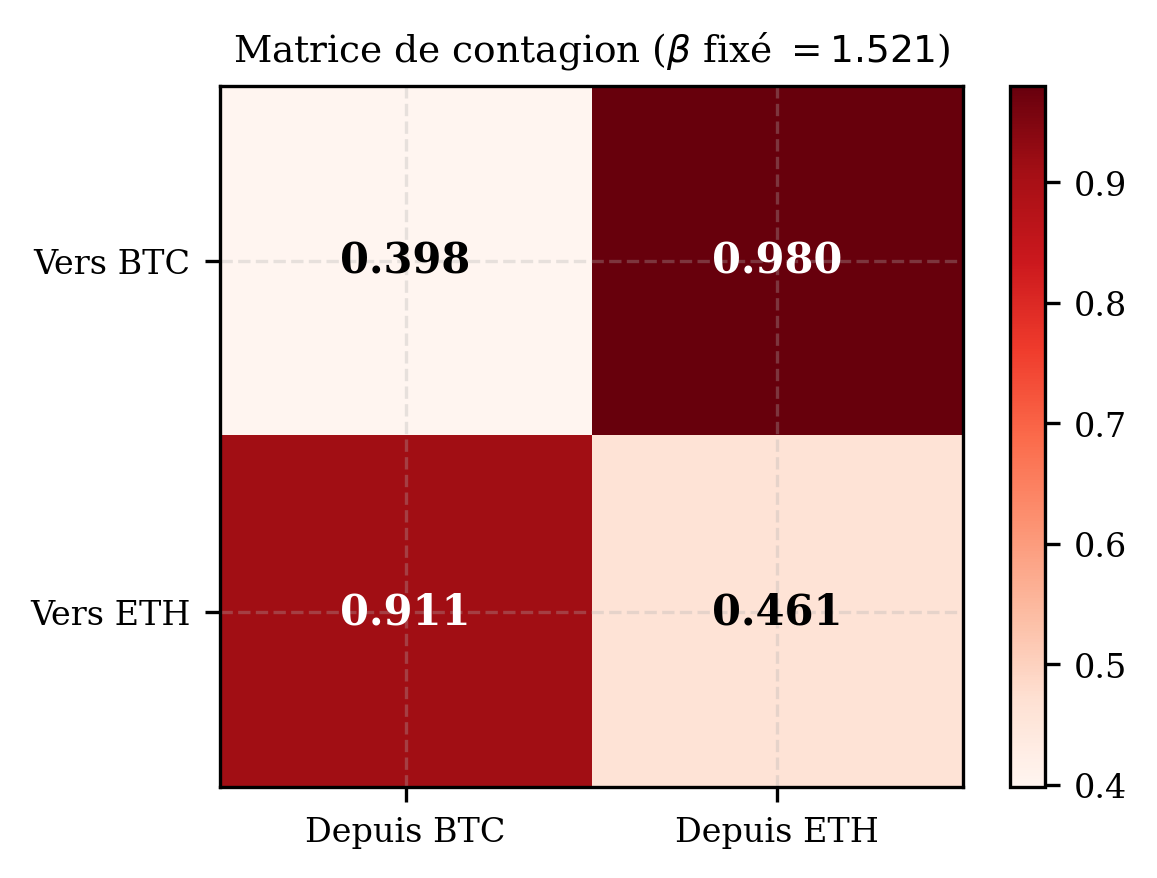

Heatmap Bloc B bis sauvegardée ✓


In [30]:
# ============================================================
# HEATMAP — Bloc B bis uniquement
# ============================================================

fig, ax = plt.subplots(1, 1, figsize=(4, 3))

im = ax.imshow(A_b2, cmap='Reds', aspect='auto')
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Depuis BTC', 'Depuis ETH'])
ax.set_yticklabels(['Vers BTC', 'Vers ETH'])
ax.set_title(r'Matrice de contagion ($\beta$ fixé $= 1.521$)')
plt.colorbar(im, ax=ax)

for i in range(2):
    for j in range(2):
        val   = A_b2[i, j]
        color = 'white' if val > A_b2.max()/2 else 'black'
        ax.text(j, i, f'{val:.3f}',
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color=color)

plt.tight_layout()
plt.savefig('fig_hawkes_heatmap.pdf', bbox_inches='tight')
plt.show()
print("Heatmap Bloc B bis sauvegardée ✓")